# L3b Advanced: Recombination and Computational Cost

A binomial price model has two related representations. The __full path tree__ keeps every up/down history separate. The __recombined lattice__ merges histories that reach the same state. This notebook makes that distinction concrete and answers two questions:

> Why do asymmetric moves with $d\neq 1/u$ still recombine, and what assumptions make recombination fail?

Both questions come down to the same observation about multiplication, which we develop below.

> __Learning Objectives:__
>
> By the end of this example, you should be able to:
> * __Replacement versus recombination:__ Explain why both the up and down moves stay available at every step regardless of the path taken so far. Distinguish that statement about available moves from the separate claim that different move orders merge at the same price node.
> * __Recombination:__ Show that any two paths with the same number of up moves reach the same terminal price whenever the move factors are constant. Establish that this holds without any reciprocal restriction between the up and down factors.
> * __Computational cost and its limit:__ Compare the exponential growth in the number of path histories against the quadratic growth in the number of lattice nodes. Determine the condition under which time-dependent move factors stop two path orders from merging.

Let's get started!
___

## Setup, Data, and Prerequisites

We load DataFrames and Plots from the course environment.

> The [`include(...)` command](https://docs.julialang.org/en/v1/base/base/#include) evaluates the contents of the input source file, `Include.jl`, in the notebook's global scope. The `Include.jl` file sets paths, loads required external packages, etc. For additional information on functions and types used in this material, see the [Julia programming language documentation](https://docs.julialang.org/en/v1/).

Let's set up our code environment:

In [1]:
include(joinpath(@__DIR__, "Include.jl")); # include the Include.jl file

  Activating 

project at `~/Desktop/julia_work/CHEME-5660-CourseRepository-Fall-2026`


The `Include.jl` file activates the course project and loads the [DataFrames.jl](https://dataframes.juliadata.org/stable/), [Plots.jl](https://docs.juliaplots.org/stable/), and [PrettyTables.jl](https://ronisbr.github.io/PrettyTables.jl/stable/), and [Statistics](https://docs.julialang.org/en/v1/stdlib/Statistics/) packages. There are no local source files beyond `Include.jl` itself.

Next, we set the default plot styling:

In [2]:
default(
    fontfamily = "Helvetica",
    framestyle = :box,
    background_color = :gray97,
    background_color_outside = :white,
    legend_background_color = nothing,
    fg_legend = :transparent,
    linewidth = 2,
);

___

## Task 1: Enumerate every path

In this task, we'll fix the two lattice moves and write out all $2^N$ up-down histories, pricing each one by walking its moves in order. Keeping every history separate is what makes a full tree expensive, and it is exactly what recombination removes.

We fix the two moves $u$ and $d$ and reuse them for the rest of the notebook, choosing $d\neq 1/u$ deliberately so that nothing later depends on the moves being symmetric. At every step the model offers the same set $\{u,d\}$, which in sampling language means the moves are drawn __with replacement__: an up move today does not remove the up move from tomorrow's possibilities. Replacement says nothing about symmetry, so we can keep $d\neq 1/u$ and still draw from the same pair at every step.

Let's set the move factors and the example parameters:

In [3]:
S₀ = 100.0
u = 1.12
d = 0.94
N = 4

@assert !isapprox(d, 1 / u)
(S₀ = S₀, u = u, d = d, reciprocal_down_factor = 1 / u, steps = N)

(S₀ = 100.0, u = 1.12, d = 0.94, reciprocal_down_factor = 0.8928571428571428, steps = 4)

___

### The full path tree keeps every history

A path is a length-$N$ sequence of up and down moves, so there are $2^N$ of them. The helper below enumerates every sequence and records both the history and the terminal price it reaches.

In [4]:
function binary_paths(N::Int)
    return collect(Iterators.product(fill((:D, :U), N)...))
end

function sequential_price(path, S₀::Float64, u::Float64, d::Float64)
    price = S₀
    for move in path
        price *= move == :U ? u : d
    end
    return price
end

function full_path_table(S₀::Float64, u::Float64, d::Float64, N::Int)
    rows = NamedTuple[]
    for path in binary_paths(N)
        k = count(==(:U), path)
        push!(rows, (
            path = join(string.(path)),
            up_moves = k,
            sequential_price = sequential_price(path, S₀, u, d),
            recombined_price = S₀ * u^k * d^(N-k),
        ))
    end
    return DataFrame(rows)
end

full_path_table (generic function with 1 method)

In [5]:
paths = full_path_table(S₀, u, d, N)
@assert nrow(paths) == 2^N
@assert all(isapprox.(paths.sequential_price, paths.recombined_price))
sort(paths, [:up_moves, :path])

Row,path,up_moves,sequential_price,recombined_price
,String,Int64,Float64,Float64
1,DDDD,0,78.0749,78.0749
2,DDDU,1,93.0254,93.0254
3,DDUD,1,93.0254,93.0254
4,DUDD,1,93.0254,93.0254
5,UDDD,1,93.0254,93.0254
6,DDUU,2,110.839,110.839
7,DUDU,2,110.839,110.839
8,DUUD,2,110.839,110.839
9,UDDU,2,110.839,110.839


___

## Task 2: Collapse the paths into a lattice

In this task, we'll group the paths by their number of up moves, count the distinct terminal prices, and compare the storage cost of a full tree against a recombined lattice. Because the factors multiply, the order of the moves does not matter, and the node count drops from exponential to quadratic.

With constant $u$ and $d$, a path containing $k$ up moves and $N-k$ down moves ends at:

$$S_{N,k}=S_0u^kd^{N-k}.$$

The order of the factors never appears in that expression, so $S_0ud=S_0du$ whether or not $d=1/u$. The 16 paths enumerated above therefore collapse to only five distinct terminal states.

Let's group the paths by up-move count and count the distinct terminal prices:

In [6]:
terminal_nodes = combine(
    groupby(paths, :up_moves),
    nrow => :number_of_paths,
    :recombined_price => first => :terminal_price,
)
sort!(terminal_nodes, :up_moves)
@assert terminal_nodes.number_of_paths == [binomial(N, k) for k in 0:N]
terminal_nodes

Row,up_moves,number_of_paths,terminal_price
,Int64,Int64,Float64
1,0,1,78.0749
2,1,4,93.0254
3,2,6,110.839
4,3,4,132.063
5,4,1,157.352


___

### Recombination changes the computational cost

A full binary tree through level $t$ contains $2^{t+1}-1$ path-specific nodes, because it keeps one node per history. A recombined lattice instead keeps one node per level and up-move count, so its node count through level $t$ is given by:

$$1+2+\cdots +(t+1)=\frac{(t+1)(t+2)}{2}.$$

The first count grows exponentially with the number of levels while the second grows quadratically, which is the practical reason lattices are usable at all.

Let's count the nodes in both representations as the number of levels grows:

In [7]:
levels = 0:25
node_counts = DataFrame(
    final_level = collect(levels),
    path_histories = [big(2)^t for t in levels],
    full_tree_nodes = [big(2)^(t+1) - 1 for t in levels],
    recombined_terminal_nodes = [t + 1 for t in levels],
    recombined_total_nodes = [div((t + 1) * (t + 2), 2) for t in levels],
)
# Display the node counts at every fifth level.
pretty_table(node_counts[[1, 6, 11, 16, 21, 26], :];
    column_labels = ["Final level t", "Path histories", "Full-tree nodes",
        "Recombined terminal nodes", "Recombined total nodes"],
    table_format = TextTableFormat(borders = text_table_borders__simple),
    fit_table_in_display_horizontally = false,
    fit_table_in_display_vertically = false)

================ ================ ================= =========================== =========================
  Final level t   Path histories   Full-tree nodes   Recombined terminal nodes   Recombined total nodes 
================ ================ ================= =========================== =========================
              0                1                 1                           1                        1
              5               32                63                           6                       21
             10             1024              2047                          11                       66
             15            32768             65535                          16                      136
             20          1048576           2097151                          21                      231
             25         33554432          67108863                          26                      351
================ ================ ================= =======

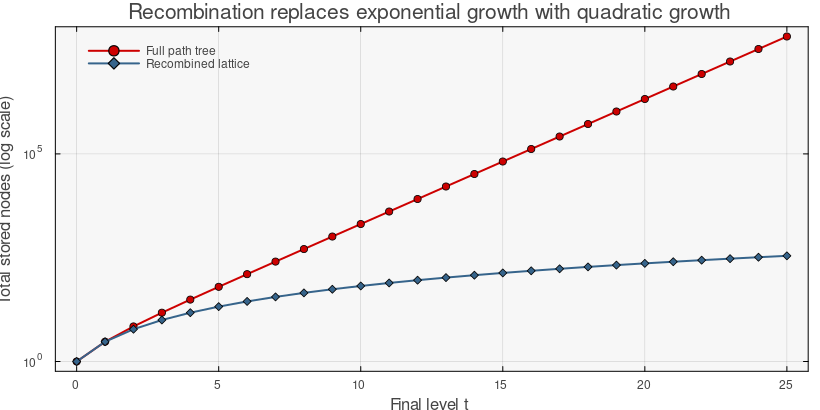

In [8]:
plot(
    node_counts.final_level, Float64.(node_counts.full_tree_nodes);
    yscale = :log10, marker = :circle, color = :red3, label = "Full path tree",
    xlabel = "Final level t", ylabel = "Total stored nodes (log scale)",
    title = "Recombination replaces exponential growth with quadratic growth",
    legend = :topleft,
    size = (820, 410),
)
plot!(node_counts.final_level, node_counts.recombined_total_nodes;
    marker = :diamond, color = :steelblue4, label = "Recombined lattice")

___

## Task 3: Break recombination with time-dependent moves

In this task, we'll let the up and down factors change from one step to the next and compare the two paths that end after two steps. Recombination is not automatic once the factors vary by step, and this comparison shows the condition it needs.

Suppose the factors depend on the step. After two steps, an up-then-down path has value $S_0u_1d_2$, while a down-then-up path has value $S_0d_1u_2$. Those two values merge only when:

$$u_1d_2=d_1u_2\qquad\Longleftrightarrow\qquad \frac{u_1}{d_1}=\frac{u_2}{d_2}.$$

Constant factors satisfy this condition automatically, while general time-dependent factors do not.

Let's compare the two two-step paths under time-dependent factors:

In [9]:
u_by_step = [1.10, 1.18]
d_by_step = [0.96, 0.91]

up_then_down = S₀ * u_by_step[1] * d_by_step[2]
down_then_up = S₀ * d_by_step[1] * u_by_step[2]

comparison = DataFrame(
    path = ["UD", "DU"],
    terminal_price = [up_then_down, down_then_up],
)
@assert !isapprox(up_then_down, down_then_up)

# Display the two two-step paths and the different prices they reach.
pretty_table(comparison;
    column_labels = ["Path", "Terminal price (USD/share)"],
    table_format = TextTableFormat(borders = text_table_borders__simple),
    fit_table_in_display_horizontally = false,
    formatters = [fmt__printf("%.4f", [2])])

======= =============================
  Path   Terminal price (USD/share) 
======= =============================
    UD                     100.1000
    DU                     113.2800
======= =============================


The move set can still be available with replacement even when the resulting structure does not recombine. Replacement describes what may be drawn next, whereas recombination describes whether different histories arrive at the same state.

Once equivalent states are merged, the picture is a directed acyclic graph rather than a tree in the strict sense. In finance, __binomial tree__ remains common shorthand for either representation.

___

## Summary

This notebook separated three statements about a binomial price model: which moves are available at each step, when different move orders merge at the same price node, and what that merging saves in storage and computation.

> __Key Takeaways:__
>
> * __Asymmetry does not prevent recombination:__ Constant positive move factors recombine because multiplication is commutative, so the order of the moves does not change the product. No reciprocal relationship between the up and down factors is required for this to hold.
> * __Replacement and recombination are different statements:__ Replacement says both moves stay available at every step. Recombination says histories that reach the same state can be merged into a single node.
> * __Recombination saves computation only while the factors are constant:__ The full path tree grows exponentially in the number of steps while the recombined lattice grows quadratically. Time-dependent move factors merge only under an additional ratio condition, so the quadratic representation is not automatic.

When a later lecture prices an asset on a lattice, check the constant-factor assumption first, because it is what licenses the quadratic representation.

___

## Disclaimer and Risks

This notebook is for instruction only. A binomial lattice is a model whose conclusions depend on its move factors, probabilities, time step, and state assumptions. It is not investment or trading advice.

___